In [1]:
## === Core Libraries ===
import numpy as np
import pandas as pd

## === Statistics ===
from scipy.stats import pearsonr, mannwhitneyu

## === Visualization ===
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FormatStrFormatter
import logomaker

## === My Modules ===
from scan import MatrixScan
from util import PWM2Score, load_obj, sci_ticks, showText


In [2]:
def load_df(lib_name):
    paths = {'C17': "../tables/PL_C17.pkl", 'C16': "../tables/PL_C16.pkl"}
    if lib_name not in paths: raise ValueError(f"Unknown library: {lib_name}")
    return pd.read_pickle(paths[lib_name])

def load_params(lib):
    p = load_obj(f"../models/Params_{lib}.pkl")
    return p, PWM2Score(p["pwm35"]), PWM2Score(p["pwm10"])

## ==== Fig 2B: Reproducibility ====

In [3]:
def show_scatter(ax, df, color='gray', alpha=0.3):
    """Create a scatter plot with logarithmic scales."""
    x = df['rep1'].values
    y = df['rep2'].values
    
    ax.scatter(x, y, s=.6, edgecolor='None', color=color, alpha=alpha)
    ax.set_xlim(np.min(x)-0.12, np.max(x)+0.12)
    ax.set_ylim(np.min(y)-0.12, np.max(y)+0.12)
    
    return x, y

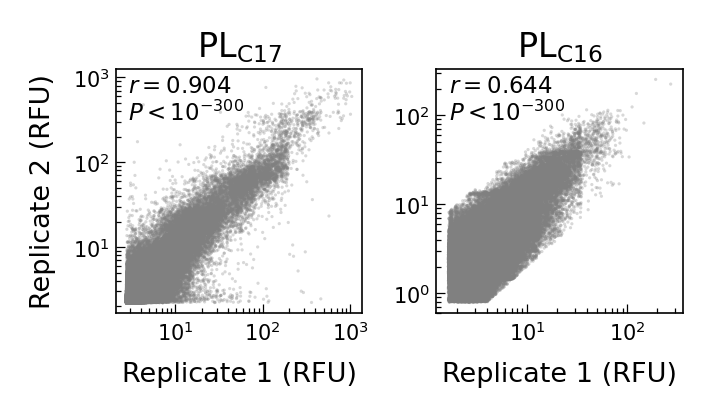

In [4]:
libs = ['C17', 'C16']
fig, axes = plt.subplots(nrows=1, ncols=len(libs), figsize=(60/25.4, 34.5/25.4), dpi=300)

for ax, lib in zip(axes, libs):
    df = load_df(lib).dropna()
    xs, ys = show_scatter(ax, df)
    r, p = pearsonr(xs, ys)
    showText(ax, f"$r={r:.3f}$", x=0.05, y=0.93, fontsize=5.5, ha='left')
    showText(ax, "$P<10^{-300}$", x=0.05, y=0.82, fontsize=5.5, ha='left')
    
    sci_ticks(ax, 'x', ticksize=5, pad=1.8)
    sci_ticks(ax, 'y', ticksize=5, pad=1.5)
    # ax.tick_params(axis='both', which='both', length=0)

axes[0].set_xlabel("Replicate 1 (RFU)", fontsize=6.5)
axes[1].set_xlabel("Replicate 1 (RFU)", fontsize=6.5)
axes[0].set_ylabel("Replicate 2 (RFU)", fontsize=6.5)

showText(axes[0], r"PL$_{\mathrm{C17}}$", x=0.5, y=1.02, fontsize=8, ha='center', va='bottom')
showText(axes[1], r"PL$_{\mathrm{C16}}$", x=0.5, y=1.02, fontsize=8, ha='center', va='bottom')

## ==== Final adjustments and saving ====
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(0.4)

plt.subplots_adjust(left=0.15, right=0.95, bottom=0.25, top=0.85, wspace=0.3)
plt.savefig("../figures/Fig2B_Reproducibility.png")
# plt.savefig("../figures/Fig2B_Reproducibility.svg")
plt.show()

## ==== Fig 2C: Violin plot ====

In [5]:
## Extract LogGFP values for each motif category
def get_motif_data(df, motif_dict):
    result = {}

    for name, func in motif_dict.items():
        mask = df.index.to_series().apply(func).values
        result[name] = df['LogGFP'][mask].values

    return result

## Draw median and interquartile ranges (25%, 50%, 75%) on violin plot
def show_quart(ax, data_arrays, positions, orient='v'):
    Q = np.array([np.percentile(arr, [25, 50, 75]) for arr in data_arrays])
    q1, med, q3 = Q[:, 0], Q[:, 1], Q[:, 2]

    if orient == 'v':
        ax.scatter(positions, med, marker='o', color='white', edgecolor='#666666', linewidth=0.5, s=12, zorder=3)
        ax.vlines(positions, q1, q3, color='#666666', lw=1.2, zorder=2)
    else:
        ax.scatter(med, positions, marker='o', color='white', edgecolor='#666666', linewidth=0.5, s=12, zorder=3)
        ax.hlines(positions, q1, q3, color='#666666', lw=1.2, zorder=2)

## Main violin plot drawing function
def plot_dist(ax, data_dict, cutoff=5.6, colors=None, orient='v', draw_quart=True):
    names = list(data_dict.keys())
    arrays = list(data_dict.values())
    n = len(names)
    pos = np.arange(n)

    if colors is None:
        colors = ['#bfbfbf'] * n

    vp = ax.violinplot(arrays, positions=pos, widths=0.5, vert=(orient == 'v'), showextrema=False)
    
    for idx, body in enumerate(vp['bodies']):
        body.set_facecolor(colors[idx])
        body.set_linewidth(0.6)
        body.set_edgecolor('#666666')
        body.set_alpha(1)

    if orient == 'v':
        ax.set_xticks(pos)
        ax.set_xticklabels([])
        ax.set_xlim(-0.6, n-0.4)
        ax.axhline(np.log10(cutoff), color='0.5', linestyle='--', linewidth=0.5, zorder=4)
    else:
        ax.set_yticks(pos)
        ax.set_yticklabels([])
        ax.set_ylim(-0.6, n-0.4)
        ax.axvline(np.log10(cutoff), color='0.5', linestyle='--', linewidth=0.5, zorder=4)

    if draw_quart:
        show_quart(ax, arrays, pos, orient)

    stats = {
        'Count': [len(a) for a in arrays],
        'FuncRatio': [np.mean(a > np.log10(cutoff)) for a in arrays]
        }
        
    return pd.DataFrame(stats, index=names)

## Show statistic significance
def show_pvalue(ax, data, pairs, alternative='less'):

    ## XY-limits
    ymin, ymax = ax.set_ylim()
    ax.set_ylim(ymin-(ymax-ymin)*.00, ymax+(ymax-ymin)*.12)
    # ax.set_xlim(-.6, 2.6)
    
    ## Compute offsets for annotation lines.
    annotation_start = ymax + 0.05  # starting point above the max value
    annotation_gap = (ymax-ymin) * 0.10  # gap between each annotation
    offs = np.linspace(annotation_start, annotation_start + annotation_gap * (len(pairs) - 1), len(pairs))
    h = (ymax-ymin) * 0.02  # you can increase this multiplier to make the line taller
    
    ## Iterate over each pair to perform the t-test and annotate significance.
    for k, (i, j) in enumerate(pairs):
        _, p = mannwhitneyu(data[i], data[j], alternative=alternative)
        if p < 10**(-100):
            sig = '∗∗∗'
        elif p < 10**(-10):
            sig = '∗∗'
        elif p < 0.05:
            sig = '∗'
        else:
            sig = 'n.s.'
        k = 0
        ax.plot([i, i, j, j], [offs[k], offs[k] + h, offs[k] + h, offs[k]], lw=0.6, c='k', clip_on=False)
        ax.text((i+j)/2, offs[k] + h, sig, ha='center', va='bottom', fontsize=5)
        print(p)

    return None

In [6]:
## Define motif categories with corresponding filtering rules
motif_configs = {
    'Whole library': lambda seq: True,
    '-35 TTGnnn':    lambda seq: seq[:3] == 'TTG',
    '-10 TAnnnT':    lambda seq: (seq[-6:-4] == 'TA') & (seq[-1] == 'T'),
    '-35 TTGACA':    lambda seq: seq[:6] == 'TTGACA',
    '-10 TATAAT':    lambda seq: seq[-6:] == 'TATAAT',
    }

## Violin plot colors for each motif category
colors = ["#bfbfbf", "#9999ff", "#ff9999", "#9999ff", "#ff9999"]

4.0930431823160803e-250
6.054762217315764e-36
2.568881452112352e-183
4.7226986821027175e-28


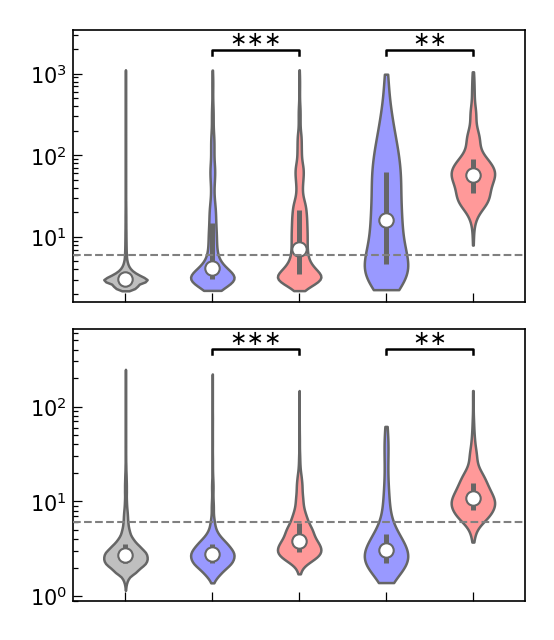

In [7]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(47.8/25.4, 53.8/25.4), dpi=300, sharex=True)

## ==== Handle C17 ====
lib = 'C17'
ax = axes[0]
df = load_df(lib)
data = get_motif_data(df, motif_configs)
stats17 = plot_dist(ax, data, cutoff=6.0, colors=colors)
show_pvalue(ax, list(data.values()), [(1, 2), (3, 4)])

ax.tick_params(axis='x', which='major', direction='in', width=0.3, length=2.1, pad=1)
yMin, yMax = ax.set_ylim()
sci_ticks(ax, 'y', ticksize=5, pad=1.5)
# showText(ax, r"PL$_{\mathrm{C17}}$", x=0.5, y=0.89, fontsize=7, ha='center', va='bottom')

## ==== Handle C16 ====
lib = 'C16'
ax = axes[1]
df = load_df(lib)
data = get_motif_data(df, motif_configs)
stats16 = plot_dist(ax, data, cutoff=6.0, colors=colors)
show_pvalue(ax, list(data.values()), [(1, 2), (3, 4)])

ax.tick_params(axis='x', which='major', direction='in', width=0.3, length=2.1, pad=1)
yMin, yMax = ax.set_ylim()
sci_ticks(ax, 'y', ticksize=5, pad=1.5)
# showText(ax, r"PL$_{\mathrm{C16}}$", x=0.5, y=0.89, fontsize=7, ha='center', va='bottom')

## ==== Final adjustments and saving ====
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(0.4)

plt.subplots_adjust(left=0.15, right=0.95, bottom=0.05, top=0.95, hspace=0.1)
plt.savefig("../figures/Fig2C_Violin.svg")
plt.show()

## ==== Fig 2D: Energy-to-Strength curve ====

In [8]:
def scan_hexamers(df, params, lib="C16", seq_col=None):
    pwm35, pwm10, sp = params["pwm35"], params["pwm10"], params["spacer"]
    WRAPPERS = {
        "C16": lambda s: "ACACAGCAGCAGTCAGGTACTCCATAAATGC" + s[:6] + "CTGTAGCGCAGAGGCG" + s[-6:] + "GCACACCCCTAA",
        "C17": lambda s: "CCAC" + s[:6] + "TTTTCGTCAAGATCGGC" + s[-6:] + "TCCA",
        }
    wrap = WRAPPERS[lib.upper()]
    src = (df[seq_col] if seq_col else df.index).astype(str)
    seqs = [wrap(s) for s in src]
    pwm = -(pd.concat([pwm35, pwm10], ignore_index=True))
    spacer_score = {int(k): -float(v) for k, v in sp.items()}
    ms = MatrixScan(seqs, pwm, spacer_score=spacer_score)
    out = df.copy()
    for k in ("minus35", "minus10", "spacer_length", "site10"):
        out[k] = ms.result[k].values
    return out

def stratified_sample(df, col, counts, seed=77777):
    rs = np.random.RandomState(seed)
    d = df.copy()
    d["grp"] = pd.cut(d[col], bins=len(counts))
    parts = []
    for grp, cnt in zip(d["grp"].unique(), counts):
        block = d[d["grp"] == grp]
        if block.empty:
            continue
        parts.append(block.sample(cnt, replace=True, random_state=seed))
    out = pd.concat(parts).drop(columns="grp")
    return out

def compute_energy(df, dE35, dE10, params):
    df["dE"] = df["minus35"].map(dE35) + df["minus10"].map(dE10) + df["spacer_length"].map(params["spacer"])
    return df

def predict_logexpr(dE, params):
    R, T = 0.001987, 310
    beta = 1.0/(R*T)
    B = np.exp(-beta*(dE + params["e0"]))
    return np.log10((params["rmin"] + params["rmax"]*B)/(1.0 + B))

def metrics(y, yhat):
    y, yhat = np.asarray(y, float).ravel(), np.asarray(yhat, float).ravel()
    r = np.corrcoef(y, yhat)[0,1] if y.size>1 else np.nan
    sse = np.sum((y-yhat)**2); sst = np.sum((y-y.mean())**2)
    r2 = np.nan if np.isclose(sst,0) else 1 - sse/sst
    mae = np.mean(np.abs(y-yhat))
    return {"pearson_r": r, "r2": r2, "mae": mae}

def annotate(ax, m, x=0.05, y=0.92, dy=0.11, fs=5):
    lines = [
        f"MAE$={m['mae']:.3f}$",
        f"$R^2={m['r2']:.3f}$" if np.isfinite(m["r2"]) else "$R^2=\\mathrm{NA}$",
        f"$r={m['pearson_r']:.3f}$" if np.isfinite(m["pearson_r"]) else "$r=\\mathrm{NA}$",
        ]
    for t in lines:
        showText(ax, t, x=x, y=y, fontsize=fs, ha="left", va="center")
        y -= dy

In [9]:
def plot_one(ax, lib, sampling=[2000]*10, show_stats=False):
    
    ## Configuration
    XTICKS  = {"C17": [-3, 0, 3, 6, 9], "C16": [0, 3, 6, 9, 12]}
    XLIMS   = {"C17": (-4.2, 10.2), "C16": (-1.2, 13.2)}
    YSET    = {"C17": ((0.05, 3.4), "Promoter strength"),
               "C16": ((-0.30, 3.4), None)}

    ## Loading
    df = stratified_sample(load_df(lib), "LogGFP", sampling)
    params, dE35, dE10 = load_params(lib)
    df = scan_hexamers(df, params, lib)
    df = compute_energy(df, dE35, dE10, params)

    ## Data
    ax.scatter(-df["dE"], df["LogGFP"], s=0.5, color='0.7', lw=0, alpha=1)
    ax.axhline(np.log10(6.0), color='0.4', linestyle='--', linewidth=0.5)

    ## Theory curve
    xmin, xmax = XLIMS[lib]
    xs = np.linspace(-xmax, -xmin, 200)[10:-10]
    ys = predict_logexpr(xs, params)
    ax.plot(-xs, ys, color="black", lw=1)

    ## Cosmetics
    ax.set_xlim(*XLIMS[lib]); ax.set_ylim(*YSET[lib][0])
    ax.set_xlabel(r"$-Δε_{RNAP}$ (kcal/mol)", fontsize=7, labelpad=2.5)
    ax.set_xticks(XTICKS[lib]); ax.set_xticklabels([str(t) for t in XTICKS[lib]])
    ax.tick_params(axis='x', which='both', labelsize=5, direction='in', width=0.3, length=2, pad=1)
    sci_ticks(ax, "y", ticksize=5, pad=1.5)
    yl = YSET[lib][1]
    if yl: ax.set_ylabel(yl, fontsize=6.5)
    showText(ax,  rf"PL$_{{\mathrm{{{lib[0]+lib[-2:]}}}}}$", x=0.5, y=1.02, fontsize=8, ha="center", va="bottom")
    for sp in ax.spines.values(): sp.set_linewidth(0.4)

    ## Predictions + stats
    yhat = predict_logexpr(df["dE"].values, params)
    m = metrics(df["LogGFP"].values, yhat)
    if show_stats: annotate(ax, m)

    return df, m

  0%|          | 0/20000 [00:00<?, ?it/s]

  0%|          | 0/20000 [00:00<?, ?it/s]

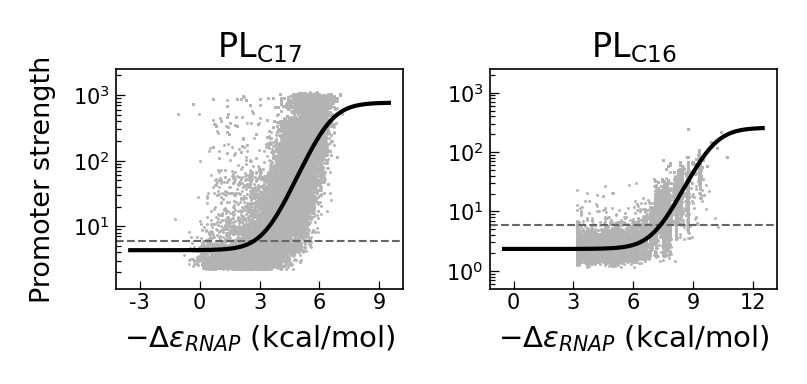

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(70/25.4, 31/25.4), dpi=300)
dfC17, mC17 = plot_one(axes[0], "C17")
dfC16, mC16 = plot_one(axes[1], "C16")
plt.subplots_adjust(left=0.15, right=0.95, bottom=0.25, top=0.85, wspace=0.3)
# plt.savefig("../figures/Fig2D_E2Scurve.png")
# plt.savefig("../figures/Fig2D_E2Scurve.svg")
plt.show()

## ==== Fig 2E: Energy logo ====

In [11]:
def LogoPlot(ax, df):
    
    ## Custom color scheme
    color_scheme = {
        'A' : 'green',
        'C' : 'blue',
        'G' : 'orange',
        'T' : 'red',
        u'АСᏀТ': '#dfdfdf'
        }

    ## Create Logo object
    pwm_logo = logomaker.Logo(df,
                              shade_below=.4,
                              fade_below=.4,
                              font_name='DejaVu Sans',
                              color_scheme=color_scheme,
                              ax=ax)
    
    ## Style using Axes methods
    pwm_logo.ax.xaxis.set_ticks_position('none')
    pwm_logo.ax.xaxis.set_tick_params(pad=-1)
    
    ## Set boundaries
    ax.axvline(5.5, color='black', lw=1, ls='--')
    ax.text(2.5, 1.6, '-35', fontsize=6.5, va='center', ha='center')
    ax.text(8.5, 1.6, '-10', fontsize=6.5, va='center', ha='center')
    
    ## Set axis limits
    ax.set_xlim(-.5, 11.5)
    ax.set_ylim(-2.1, 2.1)
    
    return pwm_logo

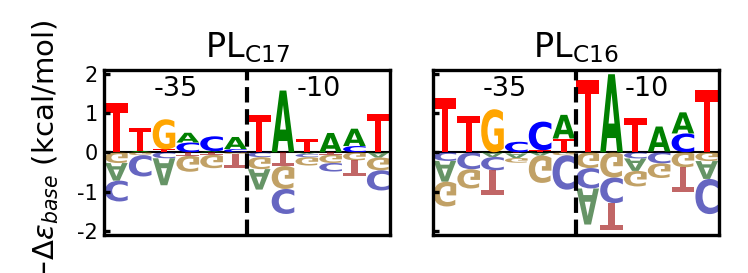

In [12]:
## Define the libraries
libs = ["C17", "C16"]

## Create a figure with two subplots (side by side)
fig, axes = plt.subplots(1, 2, figsize=(65/25.4, 20/25.4), dpi=300)

for ax, lib in zip(axes, libs):
    params, _, _ = load_params(lib)
    LogoPlot(ax, -pd.concat([params['pwm35'], params['pwm10']]).reset_index(drop=True))

    ax.set_xticks([])
    ax.set_yticks([-2, -1, 0, 1, 2])
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    ax.tick_params(axis='both', which='both', direction='in', labelsize=5, length=1.5, pad=1.5)

axes[1].set_yticklabels([])
axes[0].set_ylabel(r"$-Δε_{base}$ (kcal/mol)", fontsize=7)
axes[1].set_ylabel('')

showText(axes[0], r"PL$_{\mathrm{C17}}$", x=0.5, y=1.03, fontsize=8, ha='center', va='bottom')
showText(axes[1], r"PL$_{\mathrm{C16}}$", x=0.5, y=1.03, fontsize=8, ha='center', va='bottom')

## Manually adjust margins and spacing
plt.subplots_adjust(left=0.15, right=0.95, bottom=0.1, top=0.8, wspace=0.15)
plt.savefig(f"../figures/Fig2E_Logo.svg")
plt.show()

## ==== Fig 2G: Strength-to-Energy relationship ====

In [13]:
def scan_hexamers(df, params, lib="C16", seq_col=None):
    """Embed 12-mer (-35 + -10) into a fixed promoter template and scan."""
    pwm35, pwm10, sp = params["pwm35"], params["pwm10"], params["spacer"]
    WRAPPERS = {
        "C16": lambda s: "ACACAGCAGCAGTCAGGTACTCCATAAATGC" + s[:6] + "CTGTAGCGCAGAGGCG" + s[-6:] + "GCACACCCCTAA",
        "C17": lambda s: "CCAC" + s[:6] + "TTTTCGTCAAGATCGGC" + s[-6:] + "TCCA",
        }
    wrap = WRAPPERS[lib.upper()]
    
    src = (df[seq_col] if seq_col else df.index).astype(str)
    seqs = [wrap(s) for s in src]

    pwm = -(pd.concat([pwm35, pwm10], ignore_index=True))
    spacer_score = {int(k): -float(v) for k, v in sp.items()}

    ms = MatrixScan(seqs, pwm, spacer_score=spacer_score)
    out = df.copy()
    for k in ("minus35", "minus10", "spacer_length", "site10"):
        out[k] = ms.result[k].values
    return out

def compute_energy(df, dE35, dE10):
    df["score35"] = -df["minus35"].map(dE35)
    df["score10"] = -df["minus10"].map(dE10)
    return df

def trend_panel(ax, lib, color35="blue", color10="red"):
    
    ## Load + scan
    params, dE35, dE10 = load_params(lib)
    df = load_df(lib)
    df = scan_hexamers(df, params, lib)
    df = compute_energy(df, dE35, dE10)

    ## Bin LogGFP into 8 groups and compute midpoints
    df["group"] = pd.cut(df["LogGFP"], 8, labels=False)
    cats = pd.cut(df["LogGFP"], 8).cat.categories
    xs = np.array([(c.left + c.right) / 2 for c in cats], dtype=float)

    gb = df.groupby("group", dropna=True)
    df_mean = gb[["score10", "score35", "LogGFP"]].mean()

    ## Primary axis: -35
    ax.plot(xs, df_mean["score35"], "o-", label="-35 mean energy", color=color35, ms=3)
    ax.axvline(np.log10(6.0), color="0.4", ls="--", lw=1, alpha=1)

    ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    ax.tick_params(axis="y", labelcolor=color35, direction="in", width=0.3, length=2, pad=1, labelsize=5)
    sci_ticks(ax, "x", ticksize=5, pad=1.5)

    ## Secondary axis: -10
    ax2 = ax.twinx()
    ax2.plot(xs, df_mean["score10"], "o-", label="-10 mean energy", color=color10, ms=3)
    ax2.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    ax2.tick_params(axis="y", labelcolor=color10, direction="in", width=0.3, length=2, pad=1, labelsize=5)
    sci_ticks(ax2, "x", ticksize=5, pad=1.5)

    ## Boxss line width
    for sp in ax.spines.values():
        sp.set_linewidth(0.4)
    for sp in ax2.spines.values():
        sp.set_linewidth(0.4)

    return None

  0%|          | 0/1022018 [00:00<?, ?it/s]

  0%|          | 0/213081 [00:00<?, ?it/s]

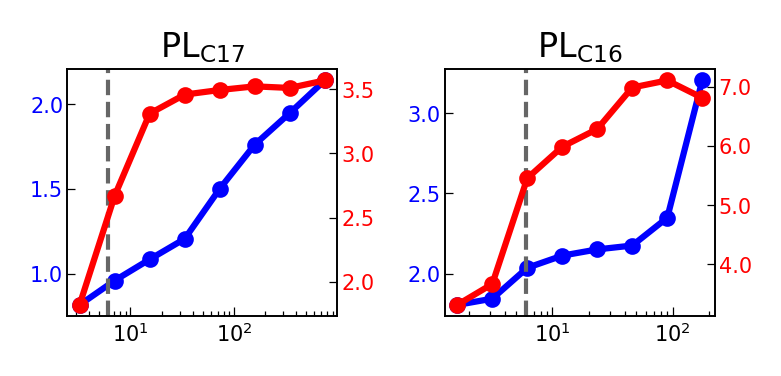

In [14]:
libs = ["C17", "C16"]
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(68.5/25.4, 24.6/25.4), dpi=300, sharex=False)
for ax, lib in zip(axes, libs):
    trend_panel(ax, lib)
    showText(ax,  rf"PL$_{{\mathrm{{{lib[0]+lib[-2:]}}}}}$", x=0.5, y=1.02, fontsize=8, ha="center", va="bottom")

plt.subplots_adjust(left=0.10, right=0.90, bottom=0.10, top=0.95, wspace=0.40)
plt.savefig("../figures/Fig2G_Trend.svg")
plt.show()